# Ecuación de Nernst

La ecuación de Nernst relaciona el potencial de equilibrio con la composición de las fases en contacto. IUPAC la expresa en función de actividades y recuerda que, en análisis químico, a menudo se usan concentraciones como aproximación práctica {cite:p}`iupac_goldbook_nernst_2025`.

En este ejemplo se usa la celda Daniell:

$$
\mathrm{Zn(s) + Cu^{2+}(aq) \rightarrow Zn^{2+}(aq) + Cu(s)}
$$

Para esta reacción, $Q = [\mathrm{Zn}^{2+}]/[\mathrm{Cu}^{2+}]$ y $n = 2$. El modelo que exploramos es:

$$
E = E^\circ - \frac{RT}{nF}\ln Q
$$

```{admonition} Qué puedes modificar
:class: dropdown
Cambia `T_values`, `[Cu2+]` o `[Zn2+]` en la celda de código. Observa que $Q=1$ devuelve $E=E^\circ$ y que el término logarítmico cambia más deprisa cuando aumenta la temperatura.
```


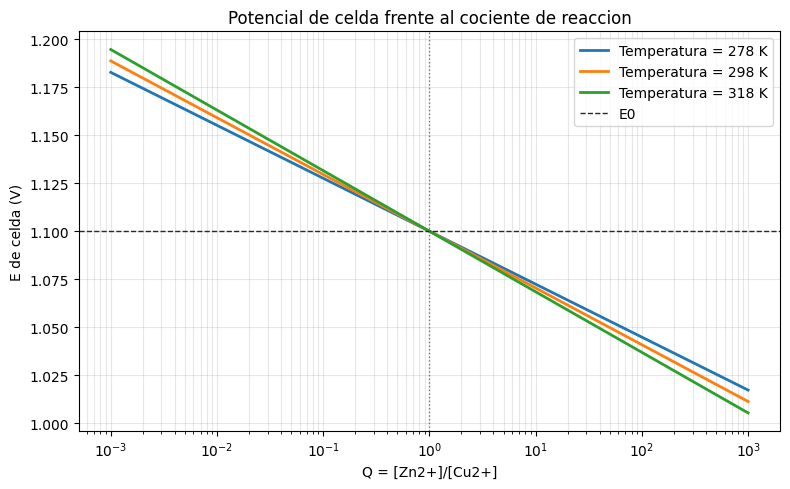

[Cu2+] = 0.010 M, [Zn2+] = 1.000 M, T = 298.15 K
Q = 100.0
E = 1.041 V


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
E0 = 1.10      # V, standard Daniell cell potential
n = 2
R = 8.314462618
F = 96485.33212
T_values = [278.15, 298.15, 318.15]
Q = np.logspace(-3, 3, 400)


def nernst(E0, T, n, Q):
    return E0 - (R * T) / (n * F) * np.log(Q)

plt.figure(figsize=(8, 5))
for T in T_values:
    plt.semilogx(Q, nernst(E0, T, n, Q), linewidth=2, label=f"Temperatura = {T:.0f} K")
plt.axhline(E0, color="#24292f", linestyle="--", linewidth=1, label="E0")
plt.axvline(1, color="#6e7781", linestyle=":", linewidth=1)
plt.xlabel("Q = [Zn2+]/[Cu2+]")
plt.ylabel("E de celda (V)")
plt.title("Potencial de celda frente al cociente de reaccion")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Cu2 = 0.010
Zn2 = 1.000
T = 298.15
Q_case = Zn2 / Cu2
E_case = nernst(E0, T, n, Q_case)
print(f"[Cu2+] = {Cu2:.3f} M, [Zn2+] = {Zn2:.3f} M, T = {T:.2f} K")
print(f"Q = {Q_case:.1f}")
print(f"E = {E_case:.3f} V")


## Interpretación

La figura computacional muestra que aumentar $Q$ desplaza la reacción hacia productos y reduce el potencial de celda. La recta vertical en $Q=1$ marca el caso estándar simplificado; a ambos lados se ve cómo el término $\ln Q$ corrige el valor de $E^\circ$.

```{admonition} Pregunta de comprobación
:class: dropdown
Si $[\mathrm{Cu}^{2+}]$ baja y $[\mathrm{Zn}^{2+}]$ sube, $Q$ aumenta. Según la ecuación, el potencial disminuye porque la celda tiene menos fuerza termodinámica disponible para avanzar en el sentido escrito.
```
